# Rolling Indian Ocean SST and IOD forecast

One ECMWF S2S issuance in; western and eastern pole temperatures, the dipole,
and calibrated SST maps out, at five lead horizons — next 30 days and weeks 1–4.

The method follows Funk's steer directly: **simple regression against NOAA OI
values** rather than quantile matching, "particularly appropriate given climate
change", with the **west and east boxes calibrated separately** and combined
afterwards. For a fixed calendar init, each climatology is just the 20-year mean
of that window, so the dipole is reported against **both** a model climatology
and an observed one.

In [1]:
import warnings, sys
warnings.filterwarnings("ignore")
sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

import africas2s as a2s
from africas2s.indices import REGIONS
import iod_pipeline as iod

INIT = "2026-08-31"
plt.rcParams.update({"figure.dpi": 130, "font.size": 9, "axes.titlesize": 10,
                     "axes.spines.top": False, "axes.spines.right": False})

WLAB = {"week1": "Week 1", "week2": "Week 2", "week3": "Week 3",
        "week4": "Week 4", "day1_30": "Days 1–30"}
POLE_C = {"wio": "#c4552f", "eio": "#1f6f80"}


def _panel_finish(ax, title):
    ax.set_title(title, fontsize=9, pad=6)
    ax.set_xticks([]); ax.set_yticks([])

## The run

`iod_pipeline.run` fetches the live forecast (100 members × 46 leads) and the
20-year on-the-fly reforecast suite keyed to the same calendar day, reduces both
to the five lead windows, pulls the OISST that verified those same windows
historically, and fits an OLS per window and pole.

In [2]:
res = iod.run(INIT, verbose=False)
years = res["years"]
print(f"init {res['init']}   reforecast years {years[0]}–{years[-1]} (n={len(years)})")
print(f"windows: {', '.join(iod.WINDOWS)}")
for w in iod.WINDOWS:
    a, b = iod.window_valid_dates(INIT, w)
    print(f"  {WLAB[w]:10s} verifies {a.date()} → {b.date()}")

init 2026-08-31   reforecast years 2006–2025 (n=20)
windows: week1, week2, week3, week4, day1_30
  Week 1     verifies 2026-09-01 → 2026-09-07
  Week 2     verifies 2026-09-08 → 2026-09-14
  Week 3     verifies 2026-09-15 → 2026-09-21
  Week 4     verifies 2026-09-22 → 2026-09-28
  Days 1–30  verifies 2026-09-01 → 2026-09-30


## The two poles, as separate results

Both in absolute °C, which is what makes the deck's ~29 °C western-pole
threshold directly readable. `slope` is the regression's correction: above 1
means the model under-disperses that pole and the fit stretches it.

In [3]:
for pole in iod.POLES:
    t = res["poles"][pole]
    show = t[["raw", "calibrated", "obs_clim", "slope", "fit_r", "loyo_r", "loyo_rmse"]]
    print(f"\n=== {pole.upper()} — {'western' if pole == 'wio' else 'eastern'} pole (°C) ===")
    print(show.round(3).to_string())


=== WIO — western pole (°C) ===
            raw  calibrated  obs_clim  slope  fit_r  loyo_r  loyo_rmse
window                                                                
week1    28.465      28.348    27.655  1.040  0.899   0.880      0.155
week2    28.697      28.771    27.725  1.319  0.908   0.873      0.186
week3    28.749      28.807    27.813  1.386  0.811   0.763      0.283
week4    28.991      28.812    27.965  1.057  0.779   0.715      0.272
day1_30  28.754      28.698    27.806  1.187  0.865   0.824      0.205

=== EIO — eastern pole (°C) ===
            raw  calibrated  obs_clim  slope  fit_r  loyo_r  loyo_rmse
window                                                                
week1    28.653      28.350    28.081  0.799  0.906   0.883      0.252
week2    28.532      28.315    28.110  0.722  0.929   0.910      0.214
week3    28.455      28.277    28.123  0.634  0.845   0.815      0.321
week4    28.378      28.270    28.169  0.618  0.810   0.766      0.381
day1_30  28

## Is this skill, or is it just persistence?

SST is strongly autocorrelated, so a high correlation on its own says very
little — a forecast that only reproduced "the ocean stays as it is" would score
well too. The bar is what the model adds **over persistence**, here the observed
pole temperature over the 14 days before init.

In [4]:
skill_rows = []
for pole in iod.POLES:
    hcst_idx = iod.pole_series(res["fields"]["reforecast"])[pole]
    obs_idx = iod.pole_series(res["fields"]["observed"], ensemble_mean=False)[pole]
    pers = iod.persistence_predictor(INIT, years, pole)
    for w in iod.WINDOWS:
        y = obs_idx.sel(window=w).values
        m = iod.loyo_skill(hcst_idx.sel(window=w).values, y)
        p = iod.loyo_skill(pers.values, y)
        skill_rows.append(dict(pole=pole.upper(), window=w, model_r=m["r"],
                               persistence_r=p["r"], gain=m["r"] - p["r"],
                               model_rmse=m["rmse"], persistence_rmse=p["rmse"]))
skill = pd.DataFrame(skill_rows)
print(skill.set_index(["pole", "window"]).round(3).to_string())

              model_r  persistence_r   gain  model_rmse  persistence_rmse
pole window                                                              
WIO  week1      0.880          0.846  0.035       0.155             0.174
     week2      0.873          0.656  0.217       0.186             0.289
     week3      0.763          0.604  0.158       0.283             0.350
     week4      0.715          0.638  0.077       0.272             0.299
     day1_30    0.824          0.738  0.086       0.205             0.244
EIO  week1      0.883          0.825  0.058       0.252             0.306
     week2      0.910          0.580  0.330       0.214             0.434
     week3      0.815          0.326  0.490       0.321             0.559
     week4      0.766          0.307  0.459       0.381             0.599
     day1_30    0.900          0.572  0.328       0.222             0.434


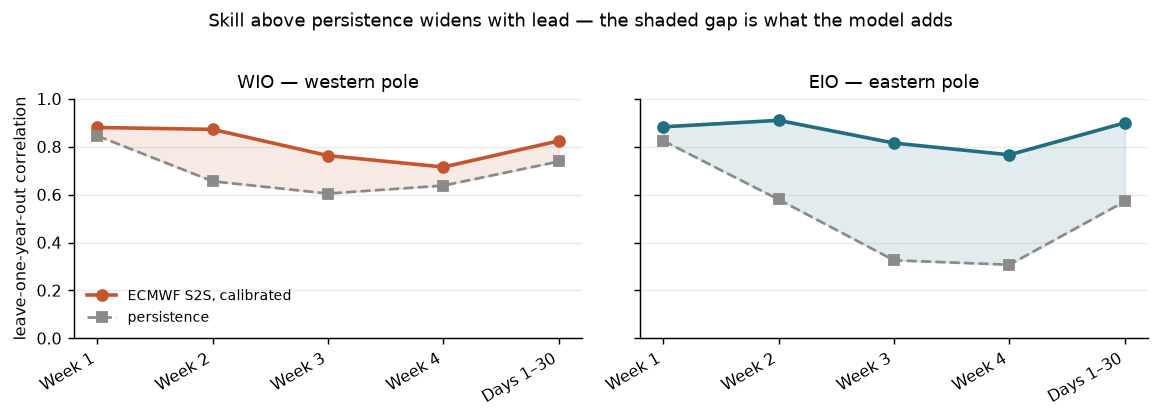

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.1), sharey=True)
for ax, pole in zip(axes, iod.POLES):
    s = skill[skill.pole == pole.upper()]
    x = np.arange(len(iod.WINDOWS))
    ax.plot(x, s.model_r, "o-", color=POLE_C[pole], lw=2, label="ECMWF S2S, calibrated")
    ax.plot(x, s.persistence_r, "s--", color="#8a8a8a", lw=1.5, label="persistence")
    ax.fill_between(x, s.persistence_r, s.model_r, color=POLE_C[pole], alpha=.13)
    ax.set_xticks(x); ax.set_xticklabels([WLAB[w] for w in iod.WINDOWS], rotation=30, ha="right")
    ax.set_ylim(0, 1); ax.grid(axis="y", alpha=.25)
    ax.set_title(f"{pole.upper()} — {'western' if pole=='wio' else 'eastern'} pole")
axes[0].set_ylabel("leave-one-year-out correlation")
axes[0].legend(frameon=False, fontsize=8, loc="lower left")
fig.suptitle("Skill above persistence widens with lead — the shaded gap is what the model adds",
             fontsize=10, y=1.02)
fig.tight_layout(); plt.show()

## The dipole, both ways

DMI is a difference of anomalies, so it inherits whatever baseline the anomaly
is taken against. Neither choice is more correct, so both are reported: the
**observed** framing asks how warm the poles are against the ocean's own recent
history; the **model** framing asks how they sit against what this model
normally predicts at this lead. The gap between them is the model's
lead-dependent bias, which the regression absorbs.

In [6]:
print(res["dmi"].round(3).to_string())

         dmi_obs_clim  dmi_model_clim  ci80_halfwidth
window                                               
week1           0.423           0.329           0.362
week2           0.841           0.509           0.336
week3           0.840           0.474           0.528
week4           0.746           0.637           0.571
day1_30         0.727           0.506           0.368


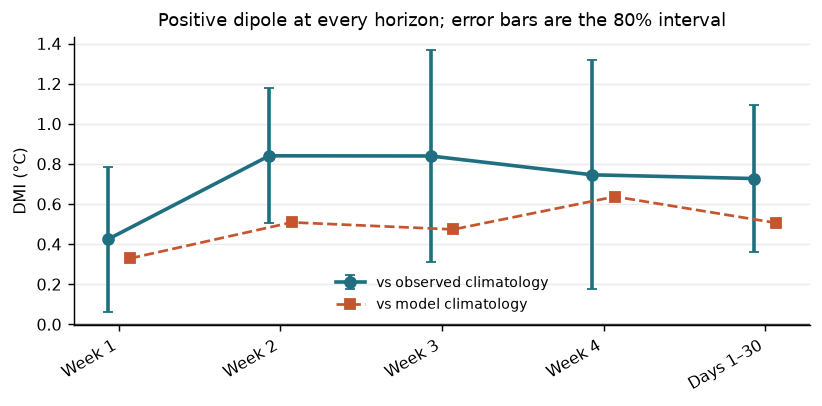

In [7]:
fig, ax = plt.subplots(figsize=(6.4, 3.2))
x = np.arange(len(iod.WINDOWS))
d = res["dmi"]
ax.errorbar(x - .07, d.dmi_obs_clim, yerr=d.ci80_halfwidth, fmt="o-",
            color="#1f6f80", lw=2, capsize=3, label="vs observed climatology")
ax.errorbar(x + .07, d.dmi_model_clim, fmt="s--", color="#c4552f", lw=1.5,
            label="vs model climatology")
ax.axhline(0, color="#444", lw=.8)
ax.set_xticks(x); ax.set_xticklabels([WLAB[w] for w in iod.WINDOWS], rotation=30, ha="right")
ax.set_ylabel("DMI (°C)"); ax.grid(axis="y", alpha=.25)
ax.legend(frameon=False, fontsize=8)
ax.set_title("Positive dipole at every horizon; error bars are the 80% interval", fontsize=10)
fig.tight_layout(); plt.show()

## Calibrated SST fields

The box-mean slope cannot be reused per grid cell — the model's bias is not
spatially uniform, which is the entire reason for calibrating a field rather
than scaling one number. So every cell gets its own regression across the 20
reforecast years. OISST is block-averaged from 0.25° to the model's 1.5° first,
so each model cell is compared against the mean of the ocean it actually covers
rather than a single point sample.

Cells where the leave-one-year-out correlation falls below 0.4 are greyed:
at week 4 a substantial part of the basin is not skilfully predicted, and a map
that hides that would overstate the product.

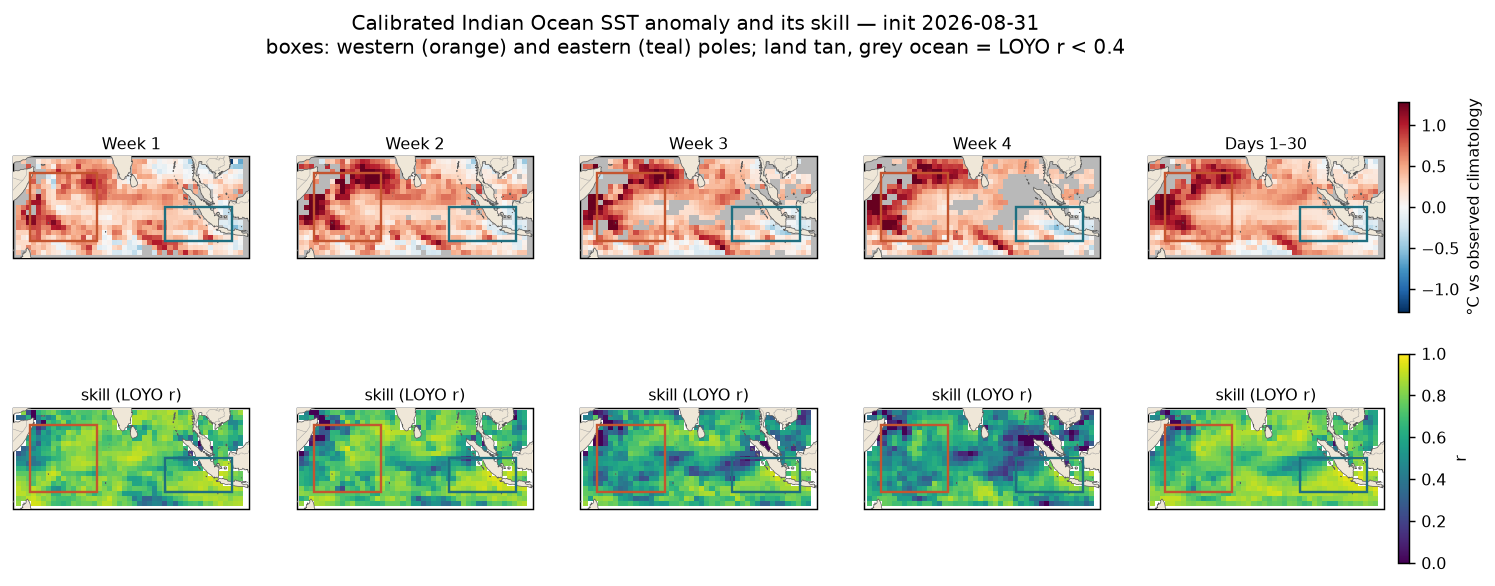

In [8]:
import cartopy.crs as ccrs, cartopy.feature as cfeature

cf = res["calibrated_fields"]
anom = cf.calibrated_sst - cf.obs_climatology
lim = float(np.nanpercentile(np.abs(anom.values), 98))
norm = TwoSlopeNorm(vcenter=0, vmin=-lim, vmax=lim)
proj = ccrs.PlateCarree()
SKILL_FLOOR, MASK_GREY, LAND_TAN = 0.4, "#b9b9b9", "#efe7d8"

def _basemap(ax):
    ax.add_feature(cfeature.LAND.with_scale("50m"), facecolor=LAND_TAN, edgecolor="none", zorder=3)
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), lw=0.4, edgecolor="#5a5a5a", zorder=4)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), lw=0.25, edgecolor="#9a9a9a", zorder=4)
    ax.set_extent([45, 115, -15, 15], crs=proj)
    for box, c in (("wtio", "#c4552f"), ("setio", "#1f6f80")):
        b = REGIONS[box]
        ax.add_patch(plt.Rectangle((b["west"], b["south"]), b["east"] - b["west"],
                                   b["north"] - b["south"], fill=False, ec=c, lw=1.3,
                                   transform=proj, zorder=5))

fig, axes = plt.subplots(2, 5, figsize=(14, 4.6), subplot_kw={"projection": proj})
for j, w in enumerate(iod.WINDOWS):
    # masked cells get an explicit grey: white is the colormap's own centre, so an
    # unskilful cell left blank would read as "no anomaly".
    axes[0, j].set_facecolor(MASK_GREY)
    a = anom.sel(window=w).where(cf.loyo_r.sel(window=w) >= SKILL_FLOOR)
    im = axes[0, j].pcolormesh(anom.lon, anom.lat, a, cmap="RdBu_r", norm=norm,
                               shading="auto", transform=proj, zorder=2)
    sk = axes[1, j].pcolormesh(cf.loyo_r.lon, cf.loyo_r.lat, cf.loyo_r.sel(window=w),
                               cmap="viridis", vmin=0, vmax=1, shading="auto",
                               transform=proj, zorder=2)
    for row, ttl in ((0, WLAB[w]), (1, "skill (LOYO r)")):
        _basemap(axes[row, j])
        axes[row, j].set_title(ttl, fontsize=9, pad=4)
fig.colorbar(im, ax=axes[0, :].tolist(), fraction=.018, pad=.01, label="°C vs observed climatology")
fig.colorbar(sk, ax=axes[1, :].tolist(), fraction=.018, pad=.01, label="r")
fig.suptitle(f"Calibrated Indian Ocean SST anomaly and its skill — init {INIT}\n"
             "boxes: western (orange) and eastern (teal) poles; land tan, grey ocean = LOYO r < 0.4",
             fontsize=11, y=1.03)
plt.show()

## Output

One row per index and horizon, with the calibrated value, its anomaly against
the observed climatology, an 80% interval from the regression residuals, and the
honest skill numbers beside it.

In [9]:
rows = []
for pole in iod.POLES:
    t = res["poles"][pole]
    sk = skill[skill.pole == pole.upper()].set_index("window")
    for w in iod.WINDOWS:
        vs, ve = iod.window_valid_dates(INIT, w)
        rows.append(dict(init=INIT, index=pole.upper(), window=w,
                         valid_from=vs.date(), valid_to=ve.date(),
                         calibrated_C=round(t.loc[w, "calibrated"], 3),
                         anomaly_C=round(t.loc[w, "calibrated"] - t.loc[w, "obs_clim"], 3),
                         ci80=round(1.2816 * t.loc[w, "resid_sd"], 3),
                         loyo_r=round(sk.loc[w, "model_r"], 3),
                         persistence_r=round(sk.loc[w, "persistence_r"], 3),
                         skill_gain=round(sk.loc[w, "gain"], 3)))
out = pd.DataFrame(rows)
out.to_csv(f"outputs/indices_{INIT}.csv", index=False)
res["dmi"].reset_index().assign(init=INIT).to_csv(f"outputs/dmi_{INIT}.csv", index=False)
cf.to_netcdf(f"outputs/calibrated_fields_{INIT}.nc")
print(out.to_string(index=False))
print(f"\nwrote outputs/indices_{INIT}.csv, dmi_{INIT}.csv, calibrated_fields_{INIT}.nc")

      init index  window valid_from   valid_to  calibrated_C  anomaly_C  ci80  loyo_r  persistence_r  skill_gain
2026-08-31   WIO   week1 2026-09-01 2026-09-07        28.348      0.693 0.192   0.880          0.846       0.035
2026-08-31   WIO   week2 2026-09-08 2026-09-14        28.771      1.046 0.215   0.873          0.656       0.217
2026-08-31   WIO   week3 2026-09-15 2026-09-21        28.807      0.994 0.344   0.763          0.604       0.158
2026-08-31   WIO   week4 2026-09-22 2026-09-28        28.812      0.848 0.326   0.715          0.638       0.077
2026-08-31   WIO day1_30 2026-09-01 2026-09-30        28.698      0.892 0.244   0.824          0.738       0.086
2026-08-31   EIO   week1 2026-09-01 2026-09-07        28.350      0.269 0.307   0.883          0.825       0.058
2026-08-31   EIO   week2 2026-09-08 2026-09-14        28.315      0.205 0.258   0.910          0.580       0.330
2026-08-31   EIO   week3 2026-09-15 2026-09-21        28.277      0.155 0.400   0.815          0

## Caveats

* **Week 1 is barely better than persistence** (r 0.88 vs 0.85 for the west).
  At that range "the ocean stays as it is" is nearly as good, and the product's
  value is really weeks 2–4.
* **Field and index calibration disagree slightly** (0.1–0.3 °C on WIO). Fitting
  per cell then area-averaging is not the same operation as fitting the
  area-average, once slopes vary across the box. The index table is the number
  to quote for an index — it is fitted directly on the quantity being reported —
  and the maps are for spatial pattern.
* **The ensemble mean is calibrated, not the spread.** The 80% interval comes
  from regression residuals across 20 years, so it reflects historical error,
  not this week's ensemble disagreement. With 100 real-time members a
  spread-aware interval is reachable and would be the natural next step.
* **Twenty years is a short fit.** Every slope rests on 20 points; a single
  unusual year moves it. That is inherent to the on-the-fly reforecast design,
  and is why leave-one-year-out rather than in-sample skill is quoted throughout.